In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Ganti path sesuai lokasi file kamu
df = pd.read_excel('Kelas G_Fixed Call Report ~rapih.xlsx')

# Atur urutan bulan supaya grafik tampil berurutan
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

print(df.head())

   Year Month  Total Number of Calls  Total Number of Doctors Consultancy  \
0  2025   Feb                 155200                                98964   
1  2025   Jan                 130982                                87815   
2  2024   Dec                 133725                                86832   
3  2024   Nov                 153698                                93710   
4  2024   Oct                 214604                               108207   

   Number of Total Health Information  Number of Total Ambulance Information  \
0                                3777                                   5773   
1                                3217                                   4179   
2                                3634                                   3735   
3                                3010                                   4421   
4                                6307                                   5792   

   Number of Total Complaints  Number of Calls To Know A

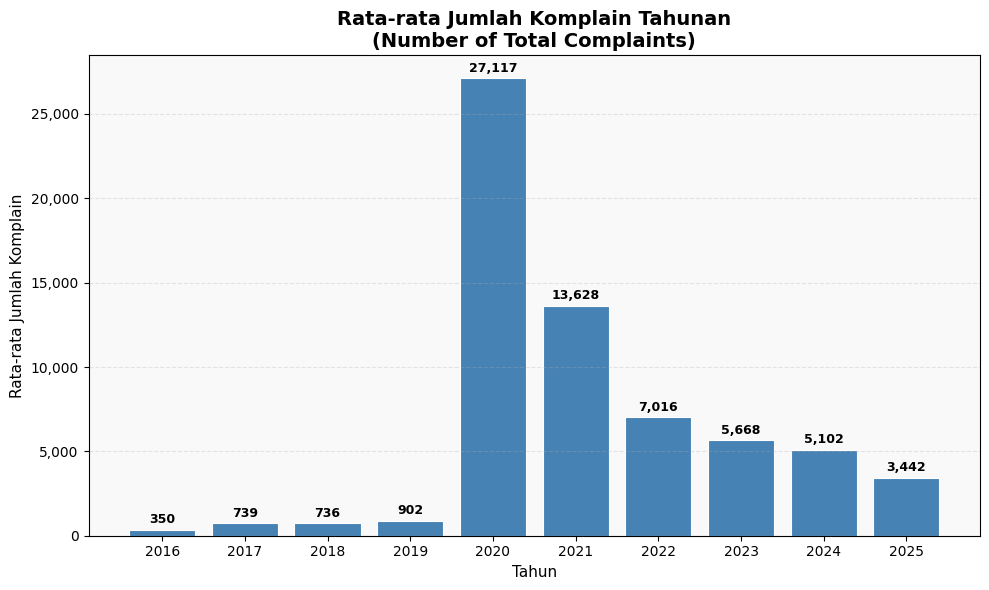

In [9]:
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Hitung rata-rata komplain per tahun dengan groupby
avg_complaints = df.groupby('Year')['Number of Total Complaints'].mean().reset_index()
avg_complaints.columns = ['Year', 'Avg_Complaints']

# Buat bar chart
bars = ax1.bar(
    avg_complaints['Year'].astype(str),
    avg_complaints['Avg_Complaints'],
    color='steelblue',
    edgecolor='white',
    linewidth=0.8
)

# Tambahkan label nilai di atas setiap bar
for bar, val in zip(bars, avg_complaints['Avg_Complaints']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,.0f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax1.set_title('Rata-rata Jumlah Komplain Tahunan\n(Number of Total Complaints)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tahun', fontsize=11)
ax1.set_ylabel('Rata-rata Jumlah Komplain', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

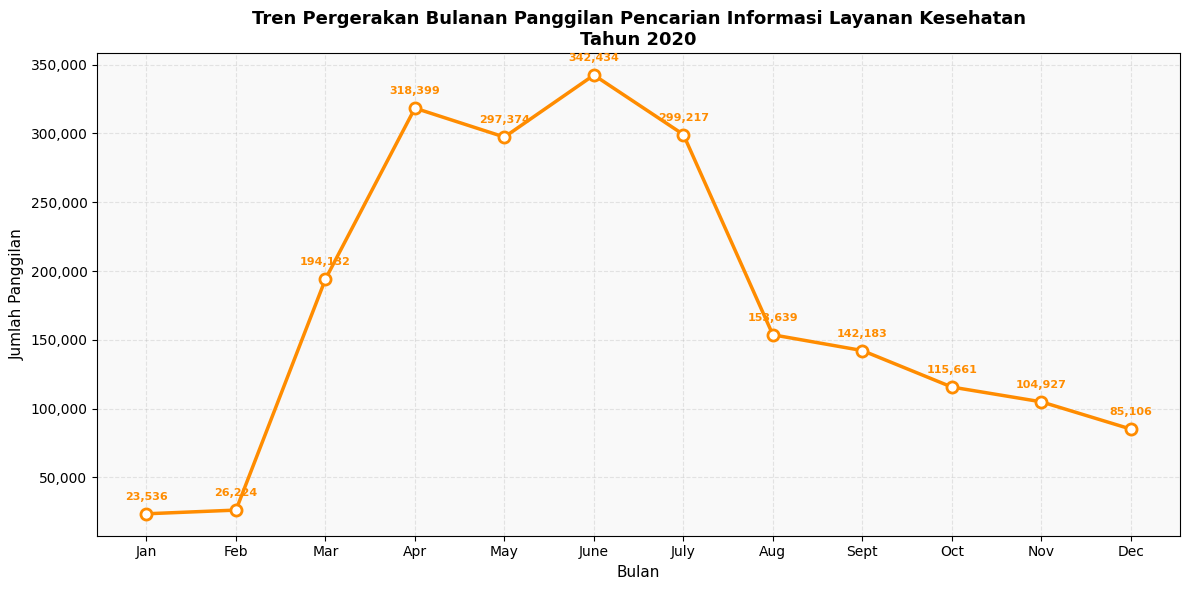

In [10]:
fig2, ax2 = plt.subplots(figsize=(12, 6))

# Filter hanya tahun 2020 dan urutkan berdasarkan bulan
df_2020 = df[df['Year'] == 2020].sort_values('Month')

# Buat line chart
ax2.plot(
    df_2020['Month'],
    df_2020['Number of Calls To Know About The Service'],
    marker='o',
    color='darkorange',
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white',
    markeredgecolor='darkorange',
    markeredgewidth=2
)

# Tambahkan label nilai di setiap titik
for _, row in df_2020.iterrows():
    ax2.annotate(
        f"{row['Number of Calls To Know About The Service']:,.0f}",
        (row['Month'], row['Number of Calls To Know About The Service']),
        textcoords='offset points', xytext=(0, 10),
        ha='center', fontsize=8, color='darkorange', fontweight='bold'
    )

ax2.set_title('Tren Pergerakan Bulanan Panggilan Pencarian Informasi Layanan Kesehatan\nTahun 2020', fontsize=13, fontweight='bold')
ax2.set_xlabel('Bulan', fontsize=11)
ax2.set_ylabel('Jumlah Panggilan', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

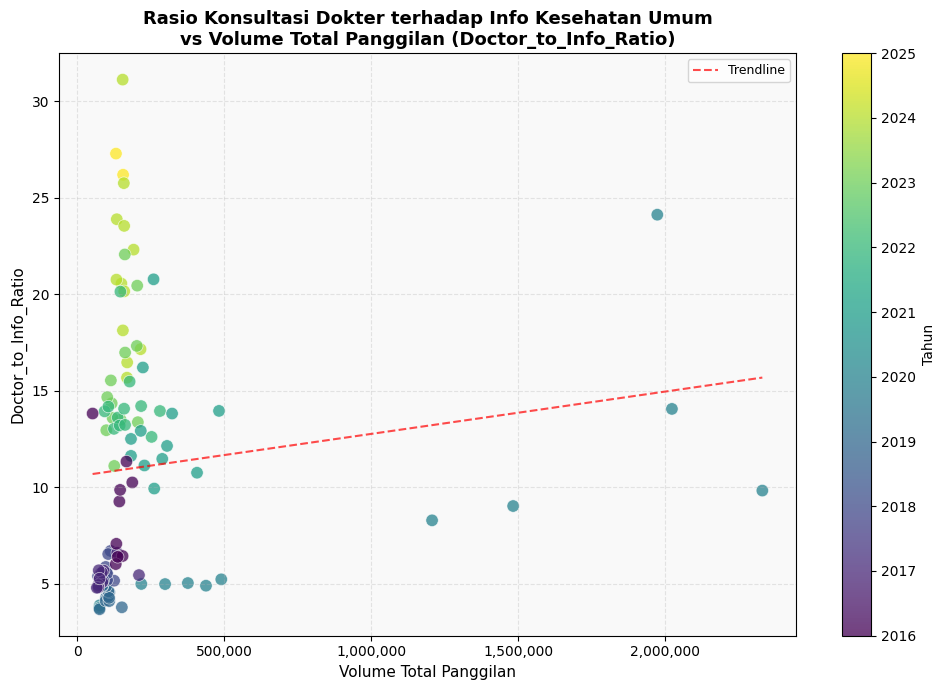

In [11]:
fig3, ax3 = plt.subplots(figsize=(10, 7))

# Buat kolom baru Doctor_to_Info_Ratio
df['Doctor_to_Info_Ratio'] = (
    df['Total Number of Doctors Consultancy'] / df['Number of Total Health Information']
)

# Scatter plot dengan warna berdasarkan tahun
scatter = ax3.scatter(
    df['Total Number of Calls'],
    df['Doctor_to_Info_Ratio'],
    c=df['Year'],
    cmap='viridis',
    alpha=0.75,
    s=80,
    edgecolors='white',
    linewidth=0.5
)

# Colorbar untuk keterangan tahun
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Tahun', fontsize=10)
cbar.set_ticks(sorted(df['Year'].unique()))

# Tambahkan trendline
z = np.polyfit(df['Total Number of Calls'], df['Doctor_to_Info_Ratio'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Total Number of Calls'].min(), df['Total Number of Calls'].max(), 200)
ax3.plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.7, label='Trendline')
ax3.legend(fontsize=9)

ax3.set_title('Rasio Konsultasi Dokter terhadap Info Kesehatan Umum\nvs Volume Total Panggilan (Doctor_to_Info_Ratio)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Volume Total Panggilan', fontsize=11)
ax3.set_ylabel('Doctor_to_Info_Ratio', fontsize=11)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.grid(alpha=0.3, linestyle='--')
ax3.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

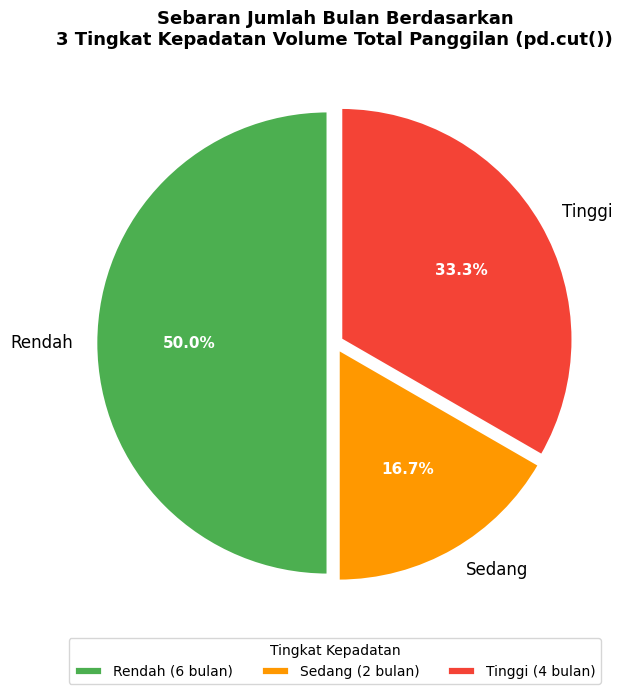

In [12]:
fig4, ax4 = plt.subplots(figsize=(9, 7))

# Hitung total panggilan per bulan (semua tahun digabung)
monthly_total = df.groupby('Month', observed=True)['Total Number of Calls'].sum().reset_index()
monthly_total.columns = ['Month', 'Total_Calls']

# Bagi ke 3 tingkat kepadatan menggunakan pd.cut()
monthly_total['Density_Level'] = pd.cut(
    monthly_total['Total_Calls'],
    bins=3,
    labels=['Rendah', 'Sedang', 'Tinggi']
)

# Hitung jumlah bulan per tingkat kepadatan
density_count = monthly_total['Density_Level'].value_counts().reindex(['Rendah', 'Sedang', 'Tinggi'])

# Buat pie chart
colors = ['#4CAF50', '#FF9800', '#F44336']
wedges, texts, autotexts = ax4.pie(
    density_count,
    labels=density_count.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.03, 0.03, 0.03],
    startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

# Legend dengan jumlah bulan
legend_labels = [f'{level} ({count} bulan)' for level, count in zip(density_count.index, density_count.values)]
ax4.legend(wedges, legend_labels, title='Tingkat Kepadatan', loc='lower center',
           bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=10)

ax4.set_title('Sebaran Jumlah Bulan Berdasarkan\n3 Tingkat Kepadatan Volume Total Panggilan (pd.cut())', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

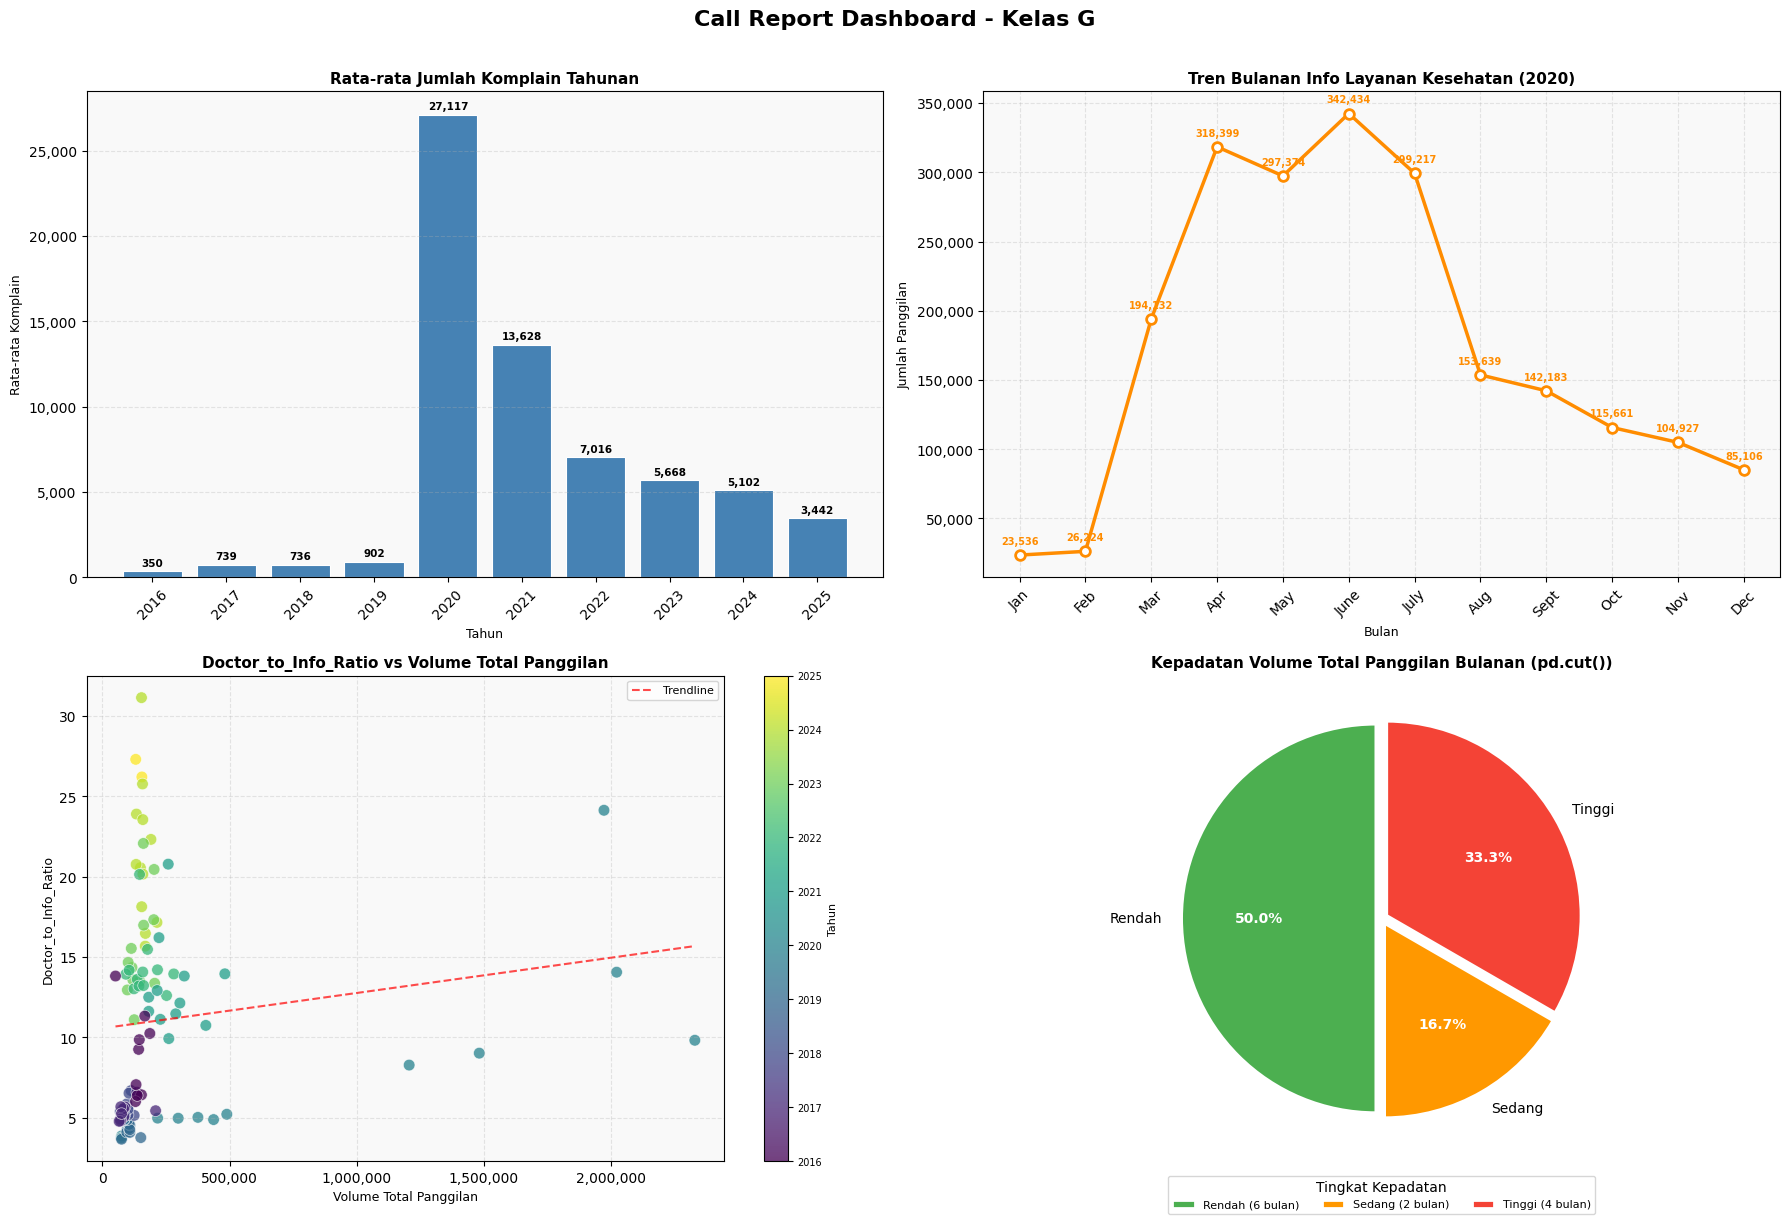

✅ Grafik gabungan 2x2 selesai! Tersimpan sebagai grafik5_gabungan_2x2.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_excel('Kelas G_Fixed Call Report ~rapih.xlsx')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)


# ============================================================
# GABUNGAN 4 GRAFIK — Grid 2x2
# ============================================================
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Call Report Dashboard - Kelas G', fontsize=16, fontweight='bold', y=1.01)


# --- SOAL 1: Bar Chart — Rata-rata Komplain Tahunan ---
avg_complaints = df.groupby('Year')['Number of Total Complaints'].mean().reset_index()
avg_complaints.columns = ['Year', 'Avg_Complaints']

bars = ax1.bar(
    avg_complaints['Year'].astype(str),
    avg_complaints['Avg_Complaints'],
    color='steelblue', edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, avg_complaints['Avg_Complaints']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,.0f}',
        ha='center', va='bottom', fontsize=7.5, fontweight='bold'
    )
ax1.set_title('Rata-rata Jumlah Komplain Tahunan', fontsize=11, fontweight='bold')
ax1.set_xlabel('Tahun', fontsize=9)
ax1.set_ylabel('Rata-rata Komplain', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_facecolor('#f9f9f9')


# --- SOAL 2: Line Chart — Tren Bulanan Info Kesehatan 2020 ---
df_2020 = df[df['Year'] == 2020].sort_values('Month')

ax2.plot(
    df_2020['Month'],
    df_2020['Number of Calls To Know About The Service'],
    marker='o', color='darkorange', linewidth=2.5,
    markersize=7, markerfacecolor='white',
    markeredgecolor='darkorange', markeredgewidth=2
)
for _, row in df_2020.iterrows():
    ax2.annotate(
        f"{row['Number of Calls To Know About The Service']:,.0f}",
        (row['Month'], row['Number of Calls To Know About The Service']),
        textcoords='offset points', xytext=(0, 8),
        ha='center', fontsize=7, color='darkorange', fontweight='bold'
    )
ax2.set_title('Tren Bulanan Info Layanan Kesehatan (2020)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Bulan', fontsize=9)
ax2.set_ylabel('Jumlah Panggilan', fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.tick_params(axis='x', rotation=45)
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_facecolor('#f9f9f9')


# --- SOAL 3: Scatter Plot — Doctor_to_Info_Ratio vs Total Panggilan ---
df['Doctor_to_Info_Ratio'] = (
    df['Total Number of Doctors Consultancy'] / df['Number of Total Health Information']
)

scatter = ax3.scatter(
    df['Total Number of Calls'],
    df['Doctor_to_Info_Ratio'],
    c=df['Year'], cmap='viridis',
    alpha=0.75, s=70,
    edgecolors='white', linewidth=0.5
)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Tahun', fontsize=8)
cbar.set_ticks(sorted(df['Year'].unique()))
cbar.ax.tick_params(labelsize=7)

z = np.polyfit(df['Total Number of Calls'], df['Doctor_to_Info_Ratio'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Total Number of Calls'].min(), df['Total Number of Calls'].max(), 200)
ax3.plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.7, label='Trendline')
ax3.legend(fontsize=8)

ax3.set_title('Doctor_to_Info_Ratio vs Volume Total Panggilan', fontsize=11, fontweight='bold')
ax3.set_xlabel('Volume Total Panggilan', fontsize=9)
ax3.set_ylabel('Doctor_to_Info_Ratio', fontsize=9)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.grid(alpha=0.3, linestyle='--')
ax3.set_facecolor('#f9f9f9')


# --- SOAL 4: Pie Chart — 3 Tingkat Kepadatan dengan pd.cut() ---
monthly_total = df.groupby('Month', observed=True)['Total Number of Calls'].sum().reset_index()
monthly_total.columns = ['Month', 'Total_Calls']

monthly_total['Density_Level'] = pd.cut(
    monthly_total['Total_Calls'],
    bins=3,
    labels=['Rendah', 'Sedang', 'Tinggi']
)
density_count = monthly_total['Density_Level'].value_counts().reindex(['Rendah', 'Sedang', 'Tinggi'])

colors = ['#4CAF50', '#FF9800', '#F44336']
wedges, texts, autotexts = ax4.pie(
    density_count,
    labels=density_count.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.03, 0.03, 0.03],
    startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

legend_labels = [f'{level} ({count} bulan)' for level, count in zip(density_count.index, density_count.values)]
ax4.legend(wedges, legend_labels, title='Tingkat Kepadatan',
           loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=8)
ax4.set_title('Kepadatan Volume Total Panggilan Bulanan (pd.cut())', fontsize=11, fontweight='bold')


# ============================================================
# SIMPAN & TAMPILKAN
# ============================================================
plt.tight_layout()
plt.savefig('grafik5_gabungan_2x2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik gabungan 2x2 selesai! Tersimpan sebagai grafik5_gabungan_2x2.png")